<a href="https://colab.research.google.com/github/Juhimishra01/AI-MotionSense-HAR/blob/main/AI_MotionSense_HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dataset Setup

>verifying that our plaatform is working or not

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


In [3]:
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: []


In [4]:
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip

In [5]:
!ls -lh

total 59M
-rw-r--r-- 1 root root  59M Oct  3 05:34 human+activity+recognition+using+smartphones.zip
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data


In [6]:
!unzip -l human+activity+recognition+using+smartphones.zip | head -30

Archive:  human+activity+recognition+using+smartphones.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     6304  2023-05-22 15:22   UCI HAR Dataset.names
 60999314  2023-05-22 15:22   UCI HAR Dataset.zip
---------                     -------
 61005618                     2 files


In [7]:
# EXTRACT this data now
!unzip -q human+activity+recognition+using+smartphones.zip
!ls

 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset.names'
 sample_data					   'UCI HAR Dataset.zip'


In [8]:
!unzip -q "UCI HAR Dataset.zip"

In [9]:
!ls

 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset'
 __MACOSX					   'UCI HAR Dataset.names'
 sample_data					   'UCI HAR Dataset.zip'


In [10]:
!find "UCI HAR Dataset" -maxdepth 2 -type f | head -30

UCI HAR Dataset/activity_labels.txt
UCI HAR Dataset/README.txt
UCI HAR Dataset/test/X_test.txt
UCI HAR Dataset/test/subject_test.txt
UCI HAR Dataset/test/y_test.txt
UCI HAR Dataset/features.txt
UCI HAR Dataset/train/y_train.txt
UCI HAR Dataset/train/subject_train.txt
UCI HAR Dataset/train/X_train.txt
UCI HAR Dataset/features_info.txt
UCI HAR Dataset/.DS_Store


In [11]:
import pandas as pd

X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    sep=r"\s+",
    header=None
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
y_train: (7352, 1)
X_test : (2947, 561)
y_test : (2947, 1)


# 2. Data Understanding

✅ Module 2 complete

You now understand the essential concepts:

Sequential data → data where order can matter
Timestep → one position/moment in a sequence
Feature → a measurement at that timestep
Sequence length → number of timesteps
Samples → number of sequences/examples
Memory/hidden state → mechanism for carrying information forward

And most importantly:

(samples, timesteps, features)

means:

How many sequences
        ×
How many timesteps per sequence
        ×
How many measurements at each timestep

# 3. EDA

In [12]:
X_train.head()
#The UCI HAR dataset provides engineered features extracted from sensor signals.

#The raw sensor signals were processed to produce a large collection of measurements/features.That's why:

#one sample
    #↓
# 561 feature values

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [13]:
feature=pd.read_csv("UCI HAR Dataset/features.txt",sep=r"\s+",header=None, names=['id', 'feature'])
feature.head(20)

,id,feature
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y
5,6,tBodyAcc-std()-Z
6,7,tBodyAcc-mad()-X
7,8,tBodyAcc-mad()-Y
8,9,tBodyAcc-mad()-Z
9,10,tBodyAcc-max()-X


In [14]:
with open("UCI HAR Dataset/activity_labels.txt", "r") as f:
    readme=f.read()
print(readme)

1 WALKING
2 WALKING_UPSTAIRS
3 WALKING_DOWNSTAIRS
4 SITTING
5 STANDING
6 LAYING



In [15]:
with open("UCI HAR Dataset/features_info.txt", "r") as f:
    features_info = f.read()

print(features_info[:5000])

Feature Selection 

The features selected for this database come from the accelerometer and gyroscope 3-axial raw signals tAcc-XYZ and tGyro-XYZ. These time domain signals (prefix 't' to denote time) were captured at a constant rate of 50 Hz. Then they were filtered using a median filter and a 3rd order low pass Butterworth filter with a corner frequency of 20 Hz to remove noise. Similarly, the acceleration signal was then separated into body and gravity acceleration signals (tBodyAcc-XYZ and tGravityAcc-XYZ) using another low pass Butterworth filter with a corner frequency of 0.3 Hz. 

Subsequently, the body linear acceleration and angular velocity were derived in time to obtain Jerk signals (tBodyAccJerk-XYZ and tBodyGyroJerk-XYZ). Also the magnitude of these three-dimensional signals were calculated using the Euclidean norm (tBodyAccMag, tGravityAccMag, tBodyAccJerkMag, tBodyGyroMag, tBodyGyroJerkMag). 

Finally a Fast Fourier Transform (FFT) was applied to some of these signals pro

# 4. Preprocessing

In [16]:
print(y_train[0].value_counts().sort_index())
activity_labels = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

0
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [17]:
# it used to convert enocded labels from 0 and gives original labels to 1 to 0;
y_train_ravel=y_train.values.ravel()-1
y_test_ravel=y_test.values.ravel()-1
print("original labels:", sorted(y_train[0].unique()))
print("encoded labels:", sorted(np.unique(y_train_ravel)))

original labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
encoded labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled,
    y_train_ravel,
    test_size=0.2,
    random_state=42,
    stratify=y_train_ravel
)

# preprocessing 2

In [20]:
!find "UCI HAR Dataset" -maxdepth 2 -type f | head -30

UCI HAR Dataset/activity_labels.txt
UCI HAR Dataset/README.txt
UCI HAR Dataset/test/X_test.txt
UCI HAR Dataset/test/subject_test.txt
UCI HAR Dataset/test/y_test.txt
UCI HAR Dataset/features.txt
UCI HAR Dataset/train/y_train.txt
UCI HAR Dataset/train/subject_train.txt
UCI HAR Dataset/train/X_train.txt
UCI HAR Dataset/features_info.txt
UCI HAR Dataset/.DS_Store


In [21]:
signal=pd.read_csv("UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt",sep=r"\s+",header=None)
print(signal.shape)

(7352, 128)


In [22]:
body_acc_x_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt",
    sep=r"\s+",
    header=None
)
body_acc_y_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt",
    sep=r"\s+",
    header=None
)

body_acc_z_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt",
    sep=r"\s+",
    header=None
)

body_gyro_x_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_x_train.txt",
    sep=r"\s+",
    header=None
)

body_gyro_y_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_y_train.txt",
    sep=r"\s+",
    header=None
)

body_gyro_z_train = pd.read_csv(
    "UCI HAR Dataset/train/Inertial Signals/body_gyro_z_train.txt",
    sep=r"\s+",
    header=None
)

In [23]:
print(body_acc_x_train.shape)
print(body_acc_y_train.shape)
print(body_acc_z_train.shape)
print(body_gyro_x_train.shape)
print(body_gyro_y_train.shape)
print(body_gyro_z_train.shape)

(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)
(7352, 128)


In [24]:
import numpy as np

X_train_seq = np.stack([
    body_acc_x_train.values,
    body_acc_y_train.values,
    body_acc_z_train.values,
    body_gyro_x_train.values,
    body_gyro_y_train.values,
    body_gyro_z_train.values
], axis=-1)

print(X_train_seq.shape)

(7352, 128, 6)


In [25]:
print(X_train_seq[0].shape)
print(X_train_seq[0][:5])
print(y_train_ravel.shape)

(128, 6)
[[0.00018085 0.01076681 0.05556068 0.03019122 0.06601362 0.02285864]
 [0.01013856 0.00657948 0.05512483 0.04371071 0.04269897 0.01031572]
 [0.00927557 0.00892888 0.04840473 0.0356878  0.07485018 0.01324969]
 [0.0050659  0.00748868 0.04977497 0.0404021  0.05731974 0.01775121]
 [0.01081025 0.00614097 0.04301314 0.04709654 0.05234284 0.00255337]]
(7352,)


In [26]:
import pandas as pd
import numpy as np

body_acc_x_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt",
    sep=r"\s+",
    header=None
)

body_acc_y_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt",
    sep=r"\s+",
    header=None
)

body_acc_z_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt",
    sep=r"\s+",
    header=None
)

body_gyro_x_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_x_test.txt",
    sep=r"\s+",
    header=None
)

body_gyro_y_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt",
    sep=r"\s+",
    header=None
)

body_gyro_z_test = pd.read_csv(
    "UCI HAR Dataset/test/Inertial Signals/body_gyro_z_test.txt",
    sep=r"\s+",
    header=None
)

print(body_acc_x_test.shape)
print(body_acc_y_test.shape)
print(body_acc_z_test.shape)
print(body_gyro_x_test.shape)
print(body_gyro_y_test.shape)
print(body_gyro_z_test.shape)

(2947, 128)
(2947, 128)
(2947, 128)
(2947, 128)
(2947, 128)
(2947, 128)


In [27]:
from sklearn.model_selection import train_test_split

X_train_seq, X_val_seq, y_train_ravel, y_val = train_test_split(
    X_train_seq,
    y_train_ravel,
    test_size=0.2,
    random_state=42,
    stratify=y_train_ravel
)

print(X_train_seq.shape)
print(X_val_seq.shape)
print(y_train_ravel.shape)
print(y_val.shape)

(5881, 128, 6)
(1471, 128, 6)
(5881,)
(1471,)


In [28]:
# fit the scaler only on scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_2d = X_train_seq.reshape(-1, 6)

scaler.fit(X_train_2d)

print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)

Mean: [-0.00070258 -0.00010399 -0.00020891  0.00195211 -0.00107264 -0.00061774]
Scale: [0.1943477  0.12293122 0.10720876 0.4079335  0.38304221 0.25624025]


In [29]:
X_test_seq = np.stack([
    body_acc_x_test.values,
    body_acc_y_test.values,
    body_acc_z_test.values,
    body_gyro_x_test.values,
    body_gyro_y_test.values,
    body_gyro_z_test.values
], axis=-1)

print(X_test_seq.shape)

(2947, 128, 6)


In [30]:
X_train_scaled = scaler.transform(
    X_train_seq.reshape(-1, 6)
).reshape(X_train_seq.shape)

X_val_scaled = scaler.transform(
    X_val_seq.reshape(-1, 6)
).reshape(X_val_seq.shape)

X_test_scaled = scaler.transform(
    X_test_seq.reshape(-1, 6)
).reshape(X_test_seq.shape)

In [31]:
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (5881, 128, 6)
Validation: (1471, 128, 6)
Test: (2947, 128, 6)


In [32]:
print(X_train_scaled.mean(axis=(0, 1)))
print(X_train_scaled.std(axis=(0, 1)))

[-1.01424108e-18 -1.34273391e-17  3.63739044e-17 -1.56780686e-17
 -5.71411255e-18  7.77991613e-17]
[1. 1. 1. 1. 1. 1.]


# 5. VANILLA RNN


In [33]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

rnn_model = Sequential([
    Input(shape=(128, 6)),
    SimpleRNN(64),
    Dense(6, activation="softmax")
])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,934 (19.27 KB)

 Trainable params: 4,934 (19.27 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
print("X:", X_train_scaled.shape)
print("y:", y_train_ravel.shape)

X: (5881, 128, 6)
y: (5881,)


In [36]:
history_rnn = rnn_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2556 - loss: 1.6487 - val_accuracy: 0.3032 - val_loss: 1.4599
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3266 - loss: 1.4159 - val_accuracy: 0.3419 - val_loss: 1.3958
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3726 - loss: 1.3442 - val_accuracy: 0.3610 - val_loss: 1.2798
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3928 - loss: 1.1986 - val_accuracy: 0.4045 - val_loss: 1.1665
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4015 - loss: 1.1481 - val_accuracy: 0.4045 - val_loss: 1.1672
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4224 - loss: 1.1209 - val_accuracy: 0.4364 - val_loss: 1.1005
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4545 - loss: 1.0704 - val_accuracy: 0.4636 - val_loss: 1.0729
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4729 - loss: 1.0515 - val_accu

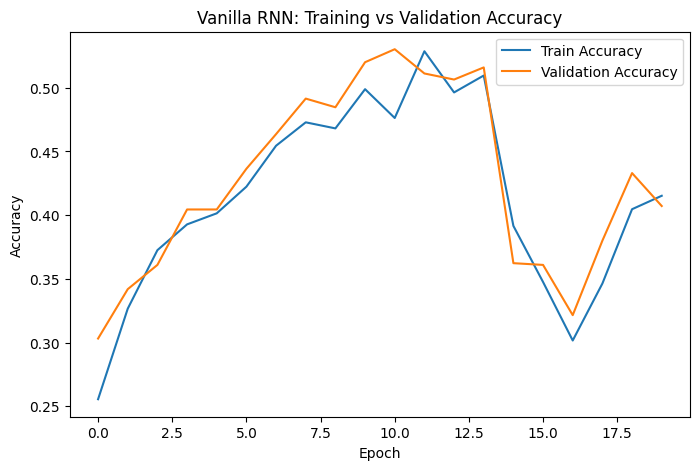

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Vanilla RNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

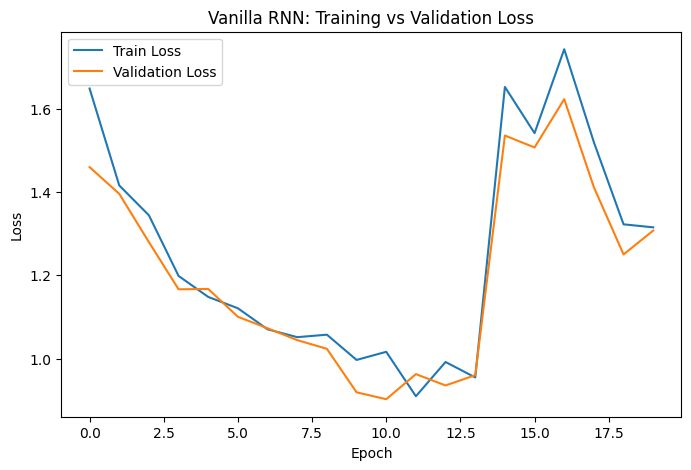

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["loss"], label="Train Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla RNN: Training vs Validation Loss")
plt.legend()
plt.show()

In [39]:
test_loss, test_accuracy = rnn_model.evaluate(
    X_test_scaled,
    y_test_ravel,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3773 - loss: 1.3467
Test Loss: 1.3467267751693726
Test Accuracy: 0.377332866191864


In [40]:
print("Final Train Accuracy:",
      history_rnn.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history_rnn.history["val_accuracy"][-1])

print("Final Train Loss:",
      history_rnn.history["loss"][-1])

print("Final Validation Loss:",
      history_rnn.history["val_loss"][-1])
print("Best Validation Accuracy:",
      max(history_rnn.history["val_accuracy"]))

Final Train Accuracy: 0.4152354896068573
Final Validation Accuracy: 0.4072059690952301
Final Train Loss: 1.3152835369110107
Final Validation Loss: 1.3075649738311768
Best Validation Accuracy: 0.5302515029907227


# 6. LSTM

In [41]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

lstm_model = Sequential([
    Input(shape=(128, 6)),
    LSTM(64),
    Dense(6, activation="softmax")
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,566 (72.52 KB)

 Trainable params: 18,566 (72.52 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history_lstm = lstm_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4639 - loss: 1.1480 - val_accuracy: 0.5860 - val_loss: 0.8511
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6064 - loss: 0.7300 - val_accuracy: 0.6207 - val_loss: 0.6510
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6169 - loss: 0.7142 - val_accuracy: 0.6179 - val_loss: 0.6636
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.6089 - loss: 0.6922 - val_accuracy: 0.6023 - val_loss: 0.7465
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6193 - loss: 0.6845 - val_accuracy: 0.6275 - val_loss: 0.6447
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.6324 - loss: 0.6348 - val_accuracy: 0.6268 - val_loss: 0.6321
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6329 - loss: 0.6190 - val_accuracy: 0.6417 - val_loss: 0.6154
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6387 - loss: 0.6151 - val_acc

In [44]:
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_scaled,
    y_test_ravel,
    verbose=1
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6288 - loss: 0.7321
LSTM Test Loss: 0.732134997844696
LSTM Test Accuracy: 0.6287750005722046


# 7. GRU

In [45]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, GRU, Dense

gru_model = Sequential([
    Input(shape=(128, 6)),
    GRU(64),
    Dense(6, activation="softmax")
])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,214 (55.52 KB)

 Trainable params: 14,214 (55.52 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
history_gru = gru_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.3826 - loss: 1.3891 - val_accuracy: 0.4922 - val_loss: 0.9902
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5380 - loss: 0.8498 - val_accuracy: 0.5826 - val_loss: 0.8013
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6098 - loss: 0.7309 - val_accuracy: 0.6349 - val_loss: 0.6464
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6315 - loss: 0.6364 - val_accuracy: 0.6295 - val_loss: 0.6186
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.6331 - loss: 0.6370 - val_accuracy: 0.6383 - val_loss: 0.6173
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6310 - loss: 0.6155 - val_accuracy: 0.6315 - val_loss: 0.6148
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6416 - loss: 0.6150 - val_accuracy: 0.6288 - val_loss: 0.6111
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.6414 - loss: 0.6101 - val_ac

In [48]:
print("Final Train Accuracy:",
      history_gru.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history_gru.history["val_accuracy"][-1])

print("Final Train Loss:",
      history_gru.history["loss"][-1])

print("Final Validation Loss:",
      history_gru.history["val_loss"][-1])

print("Best Validation Accuracy:",
      max(history_gru.history["val_accuracy"]))

Final Train Accuracy: 0.6611120700836182
Final Validation Accuracy: 0.6492182016372681
Final Train Loss: 0.5905742049217224
Final Validation Loss: 0.5862324833869934
Best Validation Accuracy: 0.6689326763153076


In [49]:
gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test_scaled,
    y_test_ravel,
    verbose=1
)

print("GRU Test Loss:", gru_test_loss)
print("GRU Test Accuracy:", gru_test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6352 - loss: 0.6832
GRU Test Loss: 0.6831855177879333
GRU Test Accuracy: 0.6352222561836243


In [50]:
y_pred_probs = lstm_model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions shape:", y_pred.shape)
print("Actual shape:", y_test_ravel.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Predictions shape: (2947,)
Actual shape: (2947,)


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_ravel,
    y_pred
)

print(cm)

[[441  28  24   1   0   2]
 [  1 462   8   0   0   0]
 [  0   7 413   0   0   0]
 [  0   0   0 443  40   8]
 [  0   0   0 483  39  10]
 [  0   0   0 466  16  55]]


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_ravel,
        y_pred,
        target_names=[
            "WALKING",
            "WALKING_UPSTAIRS",
            "WALKING_DOWNSTAIRS",
            "SITTING",
            "STANDING",
            "LAYING"
        ]
    )
)

                    precision    recall  f1-score   support

           WALKING       1.00      0.89      0.94       496
  WALKING_UPSTAIRS       0.93      0.98      0.95       471
WALKING_DOWNSTAIRS       0.93      0.98      0.95       420
           SITTING       0.32      0.90      0.47       491
          STANDING       0.41      0.07      0.12       532
            LAYING       0.73      0.10      0.18       537

          accuracy                           0.63      2947
         macro avg       0.72      0.66      0.60      2947
      weighted avg       0.71      0.63      0.58      2947



# visualization

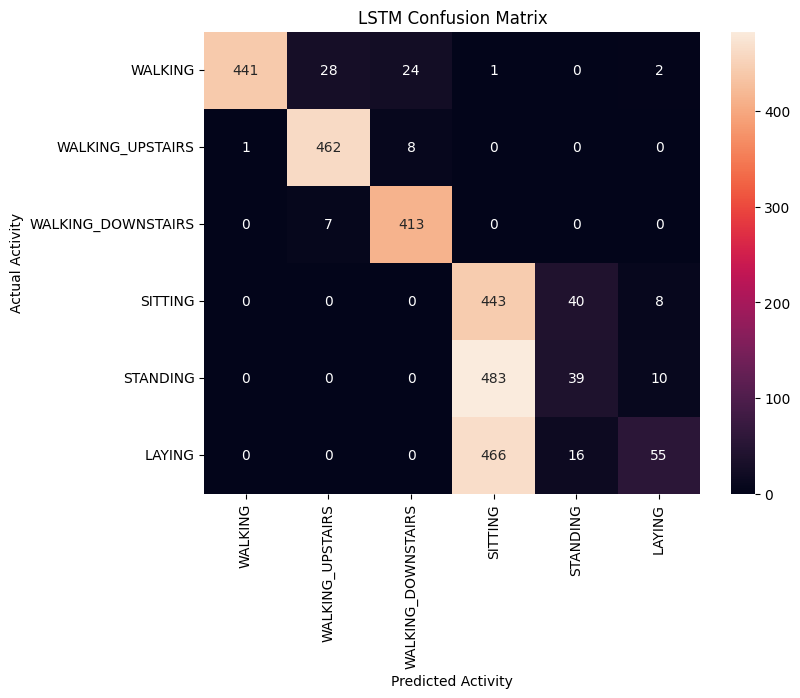

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("LSTM Confusion Matrix")
plt.show()

# Investigate the Actual Sensor Signals

In [54]:
for activity in range(6):
    index = np.where(y_test_ravel == activity)[0][0]
    print(
        activity_names[activity],
        "index:",
        index
    )

WALKING index: 79
WALKING_UPSTAIRS index: 133
WALKING_DOWNSTAIRS index: 109
SITTING index: 31
STANDING index: 0
LAYING index: 55


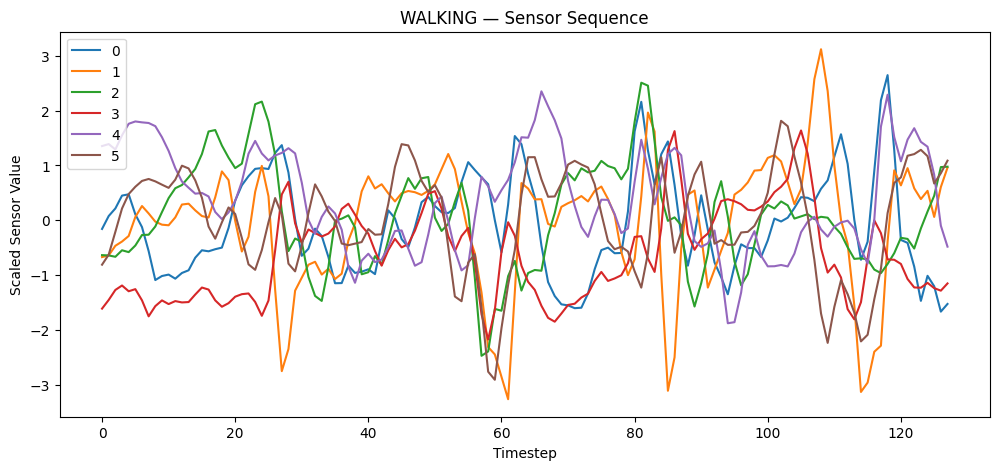

In [55]:
activity = 0

index = np.where(y_test_ravel == activity)[0][0]

sample = X_test_scaled[index]

plt.figure(figsize=(12, 5))

for feature in range(6):
    plt.plot(sample[:, feature], label=feature)

plt.title(f"{activity_names[activity]} — Sensor Sequence")
plt.xlabel("Timestep")
plt.ylabel("Scaled Sensor Value")
plt.legend()
plt.show()

# 8. Comparison



In [56]:
def plot_activity_sequence(activity_id):
    index = np.where(y_test_ravel == activity_id)[0][0]
    sample = X_test_scaled[index]

    plt.figure(figsize=(12, 5))

    for feature in range(6):
        plt.plot(sample[:, feature], label=f"Feature {feature + 1}")

    plt.title(f"{activity_names[activity_id]} — 128 Timesteps")
    plt.xlabel("Timestep")
    plt.ylabel("Scaled value")
    plt.legend()
    plt.show()

#module-lstm+ dropout

In [57]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

lstm_dropout_model = Sequential([
    Input(shape=(128, 6)),
    LSTM(64, dropout=0.2),
    Dense(6, activation="softmax")
])

lstm_dropout_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,566 (72.52 KB)

 Trainable params: 18,566 (72.52 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
lstm_dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
history_lstm_dropout = lstm_dropout_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.3763 - loss: 1.3063 - val_accuracy: 0.4616 - val_loss: 1.0869
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5125 - loss: 0.9680 - val_accuracy: 0.6057 - val_loss: 0.7684
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5824 - loss: 0.7887 - val_accuracy: 0.6349 - val_loss: 0.6789
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5936 - loss: 0.7691 - val_accuracy: 0.6302 - val_loss: 0.6602
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5967 - loss: 0.7373 - val_accuracy: 0.6349 - val_loss: 0.6909
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6213 - loss: 0.6905 - val_accuracy: 0.6193 - val_loss: 0.6345
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6140 - loss: 0.6879 - val_accuracy: 0.6343 - val_loss: 0.6245
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6184 - loss: 0.6662 - val_ac

In [60]:
print("Final Train Accuracy:",
      history_lstm_dropout.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history_lstm_dropout.history["val_accuracy"][-1])

print("Best Validation Accuracy:",
      max(history_lstm_dropout.history["val_accuracy"]))

Final Train Accuracy: 0.6318653225898743
Final Validation Accuracy: 0.6383412480354309
Best Validation Accuracy: 0.6478586196899414


In [61]:
dropout_test_loss, dropout_test_accuracy = lstm_dropout_model.evaluate(
    X_test_scaled,
    y_test_ravel,
    verbose=1
)

print("Dropout LSTM Test Loss:", dropout_test_loss)
print("Dropout LSTM Test Accuracy:", dropout_test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6064 - loss: 0.7220
Dropout LSTM Test Loss: 0.7219911813735962
Dropout LSTM Test Accuracy: 0.6063793897628784


#bidirectional lstm

In [62]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional

bilstm_model = Sequential([
    Input(shape=(128, 6)),
    Bidirectional(LSTM(64)),
    Dense(6, activation="softmax")
])

bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,126 (145.02 KB)

 Trainable params: 37,126 (145.02 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [64]:
history_bilstm = bilstm_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.4773 - loss: 1.1043 - val_accuracy: 0.6336 - val_loss: 0.7279
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6144 - loss: 0.7431 - val_accuracy: 0.6451 - val_loss: 0.7010
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6392 - loss: 0.6718 - val_accuracy: 0.6315 - val_loss: 0.6641
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6521 - loss: 0.6254 - val_accuracy: 0.6574 - val_loss: 0.6157
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6553 - loss: 0.6000 - val_accuracy: 0.6676 - val_loss: 0.6099
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6557 - loss: 0.6083 - val_accuracy: 0.6615 - val_loss: 0.6351
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6558 - loss: 0.6042 - val_accuracy: 0.6547 - val_loss: 0.6135
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6535 - loss: 0.6000 - val_a

In [65]:
print("Final Train Accuracy:",
      history_bilstm.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history_bilstm.history["val_accuracy"][-1])

print("Final Train Loss:",
      history_bilstm.history["loss"][-1])

print("Final Validation Loss:",
      history_bilstm.history["val_loss"][-1])

print("Best Validation Accuracy:",
      max(history_bilstm.history["val_accuracy"]))

Final Train Accuracy: 0.7071926593780518
Final Validation Accuracy: 0.698844313621521
Final Train Loss: 0.5502161979675293
Final Validation Loss: 0.5667302012443542
Best Validation Accuracy: 0.698844313621521


#Module 15 — BiLSTM Analysis → Test Evaluation

In [66]:
bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test_scaled,
    y_test_ravel,
    verbose=1
)

print("BiLSTM Test Loss:", bilstm_test_loss)
print("BiLSTM Test Accuracy:", bilstm_test_accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7089 - loss: 0.6136
BiLSTM Test Loss: 0.6135918498039246
BiLSTM Test Accuracy: 0.708856463432312


#Module 16.1 — Implement EarlyStopping

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [68]:
lstm_early_model = Sequential([
    Input(shape=(128, 6)),
    LSTM(64),
    Dense(6, activation="softmax")
])

lstm_early_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_early = lstm_early_model.fit(
    X_train_scaled,
    y_train_ravel,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4380 - loss: 1.2746 - val_accuracy: 0.5479 - val_loss: 0.9313
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5780 - loss: 0.8437 - val_accuracy: 0.6159 - val_loss: 0.7187
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6259 - loss: 0.6780 - val_accuracy: 0.6111 - val_loss: 0.6740
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6239 - loss: 0.6712 - val_accuracy: 0.6010 - val_loss: 0.8440
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6026 - loss: 0.7460 - val_accuracy: 0.6295 - val_loss: 0.6706
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6166 - loss: 0.6710 - val_accuracy: 0.6268 - val_loss: 0.6499
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6298 - loss: 0.6370 - val_accuracy: 0.6315 - val_loss: 0.6300
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6387 - loss: 0.6349 - val_

In [69]:
print("Epochs actually trained:", len(history_early.history["loss"]))

print("Best Validation Accuracy:",
      max(history_early.history["val_accuracy"]))

Epochs actually trained: 13
Best Validation Accuracy: 0.6369816660881042


In [70]:
y_bilstm_probs = bilstm_model.predict(X_test_scaled)
y_bilstm_pred = np.argmax(y_bilstm_probs, axis=1)

print("Predictions shape:", y_bilstm_pred.shape)
print("Actual shape:", y_test_ravel.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
Predictions shape: (2947,)
Actual shape: (2947,)


In [71]:
from sklearn.metrics import confusion_matrix

bilstm_cm = confusion_matrix(
    y_test_ravel,
    y_bilstm_pred
)

print(bilstm_cm)

[[455  15  25   0   0   1]
 [  7 442  20   0   0   2]
 [  1   4 415   0   0   0]
 [  0   3   0 114 105 269]
 [  1   0   0  47 204 280]
 [  0   0   0  37  41 459]]


In [72]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_ravel,
        y_bilstm_pred,
        target_names=[
            "WALKING",
            "WALKING_UPSTAIRS",
            "WALKING_DOWNSTAIRS",
            "SITTING",
            "STANDING",
            "LAYING"
        ]
    )
)

                    precision    recall  f1-score   support

           WALKING       0.98      0.92      0.95       496
  WALKING_UPSTAIRS       0.95      0.94      0.95       471
WALKING_DOWNSTAIRS       0.90      0.99      0.94       420
           SITTING       0.58      0.23      0.33       491
          STANDING       0.58      0.38      0.46       532
            LAYING       0.45      0.85      0.59       537

          accuracy                           0.71      2947
         macro avg       0.74      0.72      0.70      2947
      weighted avg       0.73      0.71      0.69      2947



In [73]:
bilstm_model.save("bilstm_har_model.keras")

In [74]:
import os

print("Model saved:", os.path.exists("bilstm_har_model.keras"))

Model saved: True


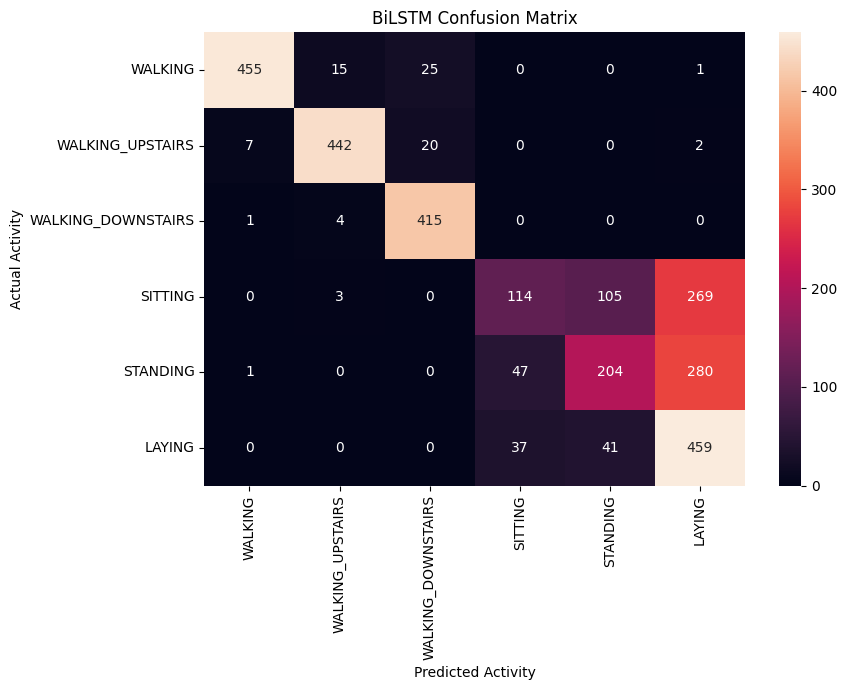

In [75]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    bilstm_cm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("BiLSTM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "bilstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_ravel,
    y_bilstm_pred,
    target_names=activity_names
)

print(report)

with open("bilstm_classification_report.txt", "w") as f:
    f.write(report)

                    precision    recall  f1-score   support

           WALKING       0.98      0.92      0.95       496
  WALKING_UPSTAIRS       0.95      0.94      0.95       471
WALKING_DOWNSTAIRS       0.90      0.99      0.94       420
           SITTING       0.58      0.23      0.33       491
          STANDING       0.58      0.38      0.46       532
            LAYING       0.45      0.85      0.59       537

          accuracy                           0.71      2947
         macro avg       0.74      0.72      0.70      2947
      weighted avg       0.73      0.71      0.69      2947



In [77]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU", "BiLSTM"],
    "Test Accuracy": [
        0.4991517,
        0.6331863,
        0.6294537,
        0.7088565
    ]
})

model_comparison["Test Accuracy (%)"] = (
    model_comparison["Test Accuracy"] * 100
).round(2)

print(model_comparison)

       Model  Test Accuracy  Test Accuracy (%)
0  SimpleRNN       0.499152              49.92
1       LSTM       0.633186              63.32
2        GRU       0.629454              62.95
3     BiLSTM       0.708857              70.89


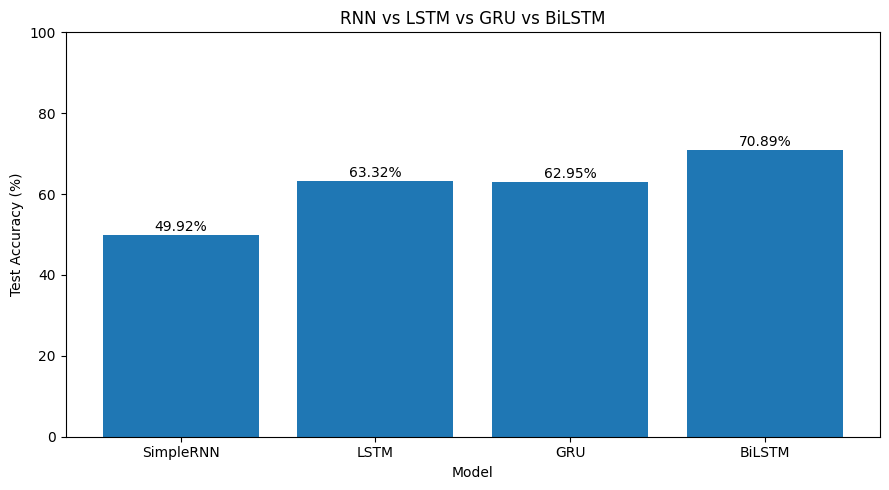

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("RNN vs LSTM vs GRU vs BiLSTM")
plt.ylim(0, 100)

for i, value in enumerate(model_comparison["Test Accuracy (%)"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

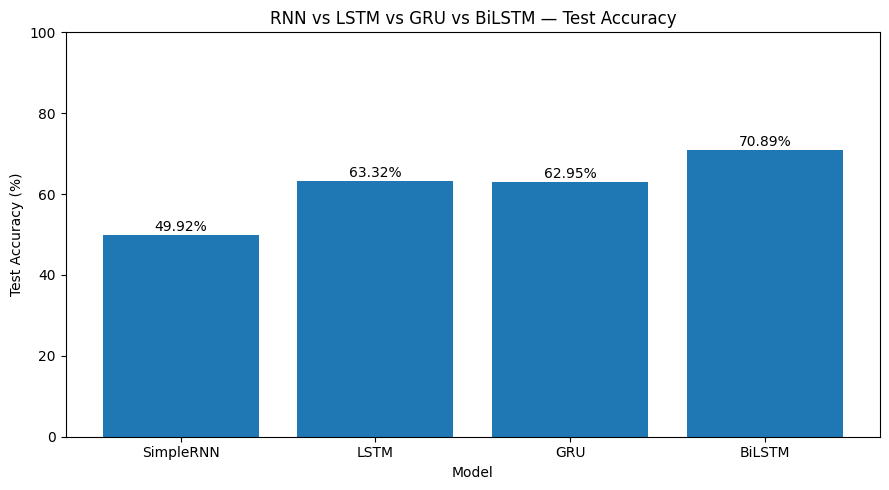

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("RNN vs LSTM vs GRU vs BiLSTM — Test Accuracy")
plt.ylim(0, 100)

for i, value in enumerate(model_comparison["Test Accuracy (%)"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

This project explored Human Activity Recognition using smartphone sensor data and recurrent neural network architectures.

SimpleRNN, LSTM, GRU, and Bidirectional LSTM models were implemented and compared.

The final Bidirectional LSTM achieved 70.89% test accuracy on the UCI HAR test set. The model performed particularly well on the three walking activities, while SITTING, STANDING, and LAYING remained more challenging to distinguish.

The experiments demonstrate how temporal sequence modeling can be applied to multi-sensor human activity recognition.